In [197]:
import requests
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from scipy.interpolate import PchipInterpolator
from scipy.interpolate import LinearNDInterpolator
from mpl_toolkits.mplot3d import Axes3D

# Question: Will BTC hit 100000 by 31DEC26?

target_expiry_str = "25DEC26"
target_expiry = datetime.strptime(target_expiry_str, "%d%b%y").strftime("%Y%m%d")
target_expiry_dt = datetime.strptime(str(target_expiry), "%Y%m%d").replace(tzinfo=timezone.utc)
required_strike = 100000.0

print("target_expiry:", target_expiry)

target_expiry: 20261225


In [ ]:
class BTCOptionSurface:
    def __init__(self, target_expiry_str):
        self.target_expiry_str = target_expiry_str

    def find_closest_expiry(self, target_expiry):

        available = list(self.curves.keys())

        target = pd.to_datetime(
            target_expiry
        )

        closest_expiry = min(
            available,
            key=lambda x: abs(
                pd.to_datetime(x) - target
            )
        )

        return closest_expiry

    def get_overall_smile(self, dr_options_df, okx_options_df, bybit_options_df):
        all_options = pd.concat([dr_options_df, okx_options_df, bybit_options_df], ignore_index=True)

        curve = all_options.groupby("strike").apply(
            lambda x: np.average(x.mark_iv, weights=x.open_interest_notional)).reset_index()

        curve.columns = ["strike", "mark_iv"]

        self.curve = curve

    def get_surface(self, dr_df, okx_df, bybit_df):
        all_options = pd.concat([dr_df, okx_df, bybit_df], ignore_index=True)

        surface = all_options.groupby(["strike", "T"]).apply( #call and put same surface, pc parity
            lambda x: np.average(x.total_variance, weights=x.open_interest_notional)).reset_index()

        surface.columns = ["strike", "T", "total_variance"]

        self.surface = surface

    def get_weighted_spot(self, dr, bybit, okx):
        spots = [dr.spot, bybit.spot, okx.spot]
        weights = [dr.volume, bybit.volume, okx.volume]

        self.weighted_spot = np.average(spots, weights=weights)

        print("weighted spot:", self.weighted_spot)

    def plot_smile(self, options_df, exchange):

        plt.plot(options_df.strike,
                options_df.mark_iv * 100,   # convert decimal IV to %
                marker="o"
            )
        
        plt.xlabel("Strike")
        plt.ylabel("Implied Volatility (%)")
        plt.title(f"{exchange} BTC {self.target_expiry_str} IV Smile")
        plt.grid(True)

        plt.show()

    def build_variance_surface(self, surface):

        points = np.column_stack(
            [
                surface["strike"],
                surface["T"]
            ]
        )

        values = surface["total_variance"]

        variance_surface = LinearNDInterpolator(
            points,
            values
        )

        return variance_surface

        # variance_surface = surface( use case
        #     #strike,
        #     #T
        # )

    def get_iv_from_surface(self, variance_surface, strike, T):

        total_variance = variance_surface(
            strike,
            T
        )

        if np.isnan(total_variance):
            return None

        iv = np.sqrt(
            total_variance / T
        )

        return float(iv)

    def plot_surface(self, surface, variance_surface):

        # surface.plot_surface( use case
        #     call_options,
        #     call_surface
        # )

        fig = plt.figure(figsize=(10, 7))

        ax = fig.add_subplot(
            111,
            projection="3d"
        )

        # Create grid
        strike_grid = np.linspace(
            surface["strike"].min(),
            surface["strike"].max(),
            50
        )

        T_grid = np.linspace(
            surface["T"].min(),
            surface["T"].max(),
            50
        )


        X, Y = np.meshgrid(
            strike_grid,
            T_grid
        )


        # Query interpolator
        variance_grid = variance_surface(
            X,
            Y
        )


        # Convert variance back to IV
        IV_grid = np.sqrt(
            variance_grid / Y
        )


        # Plot surface
        ax.plot_surface(
            X,
            Y,
            IV_grid,
            cmap="viridis",
            alpha=0.8
        )

        mark_iv = np.sqrt(
            surface["total_variance"] / surface["T"]
        )

        # Plot original points
        ax.scatter(
            surface["strike"],
            surface["T"],
            mark_iv,
            color="red",
            s=20
        )


        ax.set_xlabel("Strike")
        ax.set_ylabel("Time to Expiry (years)")
        ax.set_zlabel("Implied Volatility")


        plt.show()

    def interpolate_iv(self, options_df, required_strike):
        # Question: Will BTC hit 100000 by 31DEC26?

        # It prevents wild overshoots and spurious oscillations found in standard cubic splines, 
        # making it ideal for monotonic data, bounded physical measurements, and financial curves
        f = PchipInterpolator(options_df.strike, options_df.mark_iv)

        self.iv = float(f(required_strike))

        print(f"BTC {required_strike} strike iv: {self.iv}")

    def prob_finish(self, spot, strike, iv, T, r=0):

        d2 = (np.log(spot / strike) + (r - 0.5 * iv ** 2) * T) / (iv * np.sqrt(T))

        p_finish_above = norm.cdf(d2)
        p_finish_below = 1 - p_finish_above

        print("p_finish_above:", p_finish_above, "p_finish_below:", p_finish_below)

        return p_finish_above, p_finish_below

    def prob_touch(self, spot, strike, iv, T, r=0, paths=100000, time_steps=365):

        # dS = rSdt + σSdW
        dt = T / time_steps
        Z = np.random.normal(0, 1, size=(paths, time_steps)) # vectorization

        daily_return = ((r - 0.5 * iv ** 2) * dt + iv * np.sqrt(dt) * Z)

        prices = spot * np.exp(np.cumsum(daily_return, axis=1))

        hit_above = prices.max(axis=1) >= strike
        hit_below = prices.min(axis=1) <= strike

        self.p_touch_above = hit_above.mean()
        self.p_touch_below = hit_below.mean()

        print("p_touch_above:", self.p_touch_above, "p_touch_below:", self.p_touch_below)

        return self.p_touch_above, self.p_touch_below

surface = BTCOptionSurface(target_expiry_str)

In [178]:
class Deribit:
    def __init__(self, target_expiry):
         self.get_spot()
         self.get_df()
         self.get_smile(target_expiry)

    def get_spot(self):
        url = "https://www.deribit.com/api/v2/public/ticker"
        params = {"instrument_name": "BTC_USDT"}

        data = requests.get(url, params=params).json()["result"]
        
        self.spot = float(data["last_price"])
        self.volume = float(data["stats"]["volume"])
        print("spot:", self.spot, "volume24h:", self.volume)

    def get_df(self):
        
        url = "https://www.deribit.com/api/v2/public/get_instruments"
        params = {
            "currency": "BTC",
            "kind": "option"
        }

        instruments = requests.get(url=url, params=params).json()["result"]
        deribit_instruments_df = pd.DataFrame(instruments)

        url = "https://www.deribit.com/api/v2/public/get_book_summary_by_currency"
        params = {
            "currency": "BTC",
            "kind": "option"
        }

        quotes = requests.get(url=url, params=params).json()["result"]
        deribit_quotes_df = pd.DataFrame(quotes)

        deribit_df = deribit_instruments_df.merge(deribit_quotes_df, on="instrument_name", how="left")
        deribit_df["open_interest_notional"] = deribit_df["open_interest"] * deribit_df["contract_size"]
        deribit_df["mark_iv"] = deribit_df["mark_iv"].astype(float) / 100

        parts = deribit_df["instrument_name"].str.split("-")
        deribit_df["expiry"] = pd.to_datetime(parts.str[1], format="%d%b%y").dt.strftime("%Y%m%d")

        deribit_df["expiry_dt"] = pd.to_datetime(parts.str[1], format="%d%b%y", utc=True)
        deribit_df["T"] = (
            deribit_df["expiry_dt"] - datetime.now(timezone.utc)).dt.total_seconds() / (365.25 * 24 * 3600)
        
        deribit_df["total_variance"] = deribit_df["mark_iv"] ** 2 * deribit_df["T"]

        deribit_df = deribit_df[deribit_df["open_interest_notional"] >= 10]
        deribit_df = deribit_df.sort_values(["expiry", "strike"])

        self.deribit_df = deribit_df

    def get_smile(self, target_expiry):

        self.options_df = self.deribit_df[
            (self.deribit_df["expiry"] == target_expiry) &
            (self.deribit_df["option_type"] == "call")
        ]

        self.options_df = self.options_df.sort_values("strike")

dr = Deribit(target_expiry=target_expiry)
dr.options_df.head()

spot: 64479.0 volume24h: 6.9966


,state,price_index,kind,instrument_name,instrument_type,maker_commission,taker_commission,underlying_type,instrument_id,expiration_timestamp,...,base_currency_y,quote_currency_y,estimated_delivery_price,volume_usd,mid_price,open_interest_notional,expiry,expiry_dt,T,total_variance
542,open,btc_usd,option,BTC-25DEC26-30000-C,reversed,0.0003,0.0003,crypto,587781,1798185600000,...,BTC,BTC,64351.56,55616.06,0.54600,291.0,20261225,2026-12-25 00:00:00+00:00,0.387134,0.189913
544,open,btc_usd,option,BTC-25DEC26-35000-C,reversed,0.0003,0.0003,crypto,573922,1798185600000,...,BTC,BTC,64351.56,3003.04,0.47200,77.8,20261225,2026-12-25 00:00:00+00:00,0.387134,0.152485
546,open,btc_usd,option,BTC-25DEC26-40000-C,reversed,0.0003,0.0003,crypto,568999,1798185600000,...,BTC,BTC,64351.56,0.00,0.39925,250.9,20261225,2026-12-25 00:00:00+00:00,0.387134,0.125119
548,open,btc_usd,option,BTC-25DEC26-45000-C,reversed,0.0003,0.0003,crypto,573924,1798185600000,...,BTC,BTC,64351.56,0.00,0.32825,54.3,20261225,2026-12-25 00:00:00+00:00,0.387134,0.101961
550,open,btc_usd,option,BTC-25DEC26-50000-C,reversed,0.0003,0.0003,crypto,569001,1798185600000,...,BTC,BTC,64351.56,0.00,0.26025,260.8,20261225,2026-12-25 00:00:00+00:00,0.387134,0.084574


In [169]:
dr.deribit_df

,state,price_index,kind,instrument_name,instrument_type,maker_commission,taker_commission,underlying_type,instrument_id,expiration_timestamp,...,base_currency_y,quote_currency_y,estimated_delivery_price,volume_usd,mid_price,open_interest_notional,expiry,expiry_dt,T,total_variance
5,open,btc_usd,option,BTC-6AUG26-58000-P,reversed,0.0003,0.0003,crypto,669534,1786003200000,...,BTC,BTC,64333.51,0.00,NaN,32.5,20260806,2026-08-06 00:00:00+00:00,0.001143,0.000300
7,open,btc_usd,option,BTC-6AUG26-59000-P,reversed,0.0003,0.0003,crypto,669536,1786003200000,...,BTC,BTC,64333.51,229.40,NaN,45.2,20260806,2026-08-06 00:00:00+00:00,0.001143,0.000289
9,open,btc_usd,option,BTC-6AUG26-60000-P,reversed,0.0003,0.0003,crypto,669538,1786003200000,...,BTC,BTC,64333.51,74.43,NaN,30.0,20260806,2026-08-06 00:00:00+00:00,0.001143,0.000289
11,open,btc_usd,option,BTC-6AUG26-60500-P,reversed,0.0003,0.0003,crypto,669821,1786003200000,...,BTC,BTC,64333.51,19.90,NaN,32.4,20260806,2026-08-06 00:00:00+00:00,0.001143,0.000254
13,open,btc_usd,option,BTC-6AUG26-61000-P,reversed,0.0003,0.0003,crypto,669540,1786003200000,...,BTC,BTC,64333.51,76.55,NaN,91.7,20260806,2026-08-06 00:00:00+00:00,0.001143,0.000206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
826,open,btc_usd,option,BTC-25JUN27-140000-C,reversed,0.0003,0.0003,crypto,652118,1813910400000,...,BTC,BTC,64333.51,1130.62,0.00775,207.9,20270625,2027-06-25 00:00:00+00:00,0.885469,0.164333
828,open,btc_usd,option,BTC-25JUN27-150000-C,reversed,0.0003,0.0003,crypto,652120,1813910400000,...,BTC,BTC,64333.51,105.72,0.00575,89.0,20270625,2027-06-25 00:00:00+00:00,0.885469,0.170182
830,open,btc_usd,option,BTC-25JUN27-160000-C,reversed,0.0003,0.0003,crypto,652122,1813910400000,...,BTC,BTC,64333.51,25.01,0.00435,513.6,20270625,2027-06-25 00:00:00+00:00,0.885469,0.176055
832,open,btc_usd,option,BTC-25JUN27-170000-C,reversed,0.0003,0.0003,crypto,664078,1813910400000,...,BTC,BTC,64333.51,19.24,0.00330,20.2,20270625,2027-06-25 00:00:00+00:00,0.885469,0.181947


In [163]:
dr.all_options_df

,state,price_index,kind,instrument_name,instrument_type,maker_commission,taker_commission,underlying_type,instrument_id,expiration_timestamp,...,mark_iv,underlying_price,underlying_index,base_currency_y,quote_currency_y,estimated_delivery_price,volume_usd,mid_price,open_interest_notional,expiry
5,open,btc_usd,option,BTC-6AUG26-58000-P,reversed,0.0003,0.0003,crypto,669534,1786003200000,...,0.5126,64015.02,BTC-6AUG26,BTC,BTC,63996.44,0.00,NaN,32.5,20260806
7,open,btc_usd,option,BTC-6AUG26-59000-P,reversed,0.0003,0.0003,crypto,669536,1786003200000,...,0.5025,64015.02,BTC-6AUG26,BTC,BTC,63996.44,229.40,NaN,45.2,20260806
9,open,btc_usd,option,BTC-6AUG26-60000-P,reversed,0.0003,0.0003,crypto,669538,1786003200000,...,0.5025,64015.56,BTC-6AUG26,BTC,BTC,63996.44,74.43,NaN,30.0,20260806
11,open,btc_usd,option,BTC-6AUG26-60500-P,reversed,0.0003,0.0003,crypto,669821,1786003200000,...,0.4709,64015.02,BTC-6AUG26,BTC,BTC,63996.44,19.90,NaN,32.4,20260806
13,open,btc_usd,option,BTC-6AUG26-61000-P,reversed,0.0003,0.0003,crypto,669540,1786003200000,...,0.4243,64015.02,BTC-6AUG26,BTC,BTC,63996.44,76.55,NaN,91.7,20260806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
826,open,btc_usd,option,BTC-25JUN27-140000-C,reversed,0.0003,0.0003,crypto,652118,1813910400000,...,0.4320,66528.69,BTC-25JUN27,BTC,BTC,63996.44,1130.62,0.00775,207.9,20270625
828,open,btc_usd,option,BTC-25JUN27-150000-C,reversed,0.0003,0.0003,crypto,652120,1813910400000,...,0.4396,66528.69,BTC-25JUN27,BTC,BTC,63996.44,105.72,0.00575,89.0,20270625
830,open,btc_usd,option,BTC-25JUN27-160000-C,reversed,0.0003,0.0003,crypto,652122,1813910400000,...,0.4468,66528.69,BTC-25JUN27,BTC,BTC,63996.44,25.01,0.00435,513.6,20270625
832,open,btc_usd,option,BTC-25JUN27-170000-C,reversed,0.0003,0.0003,crypto,664078,1813910400000,...,0.4543,66528.69,BTC-25JUN27,BTC,BTC,63996.44,19.24,0.00325,20.2,20270625


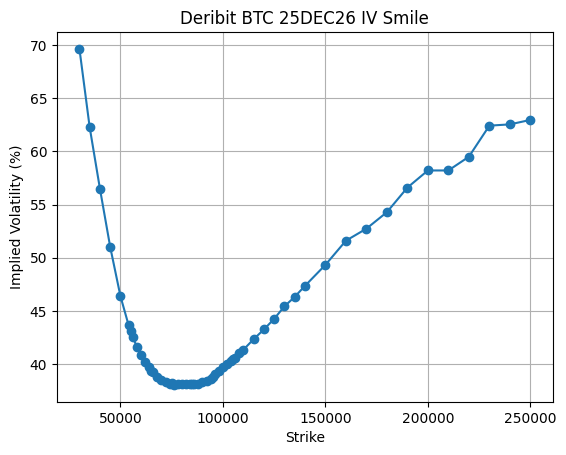

In [137]:
surface.plot_smile(options_df=dr.options_df, exchange="Deribit")

In [179]:
class OKX:
    def __init__(self, target_expiry):
         self.get_spot()
         self.get_df()
         self.get_smile(target_expiry)

    def get_spot(self):
        url = "https://www.okx.com/api/v5/market/ticker"
        params = {"instId": "BTC-USDT"}

        data = requests.get(url=url, params=params).json()["data"][0]

        self.spot = float(data["last"])
        self.volume = float(data["vol24h"])
        print("spot:", self.spot, "volume24h:", self.volume)

    def get_df(self):

        url = "https://www.okx.com/api/v5/public/instruments?instType=OPTION&uly=BTC-USD"
        data = requests.get(url).json()
        contract_size = float(data["data"][0]["ctVal"])
        
        url = "https://www.okx.com/api/v5/public/open-interest"
        params = {
            "instType": "OPTION",
            "uly": "BTC-USD"
        }

        oi = requests.get(url=url, params=params).json()["data"]
        oi_df = pd.DataFrame(oi)
        oi_df = oi_df.rename(columns={"oi": "open_interest"})
        oi_df["open_interest"] = oi_df["open_interest"].astype(float)
        oi_df["open_interest_notional"] = oi_df["open_interest"] * contract_size

        url = "https://www.okx.com/api/v5/public/opt-summary"
        params = {"uly": "BTC-USD"}

        summary = requests.get(url=url, params=params).json()["data"]
        summary_df = pd.DataFrame(summary)
        summary_df = summary_df.rename(columns={"markVol": "mark_iv"})
        summary_df["mark_iv"] = summary_df["mark_iv"].astype(float)

        parts = summary_df["instId"].str.split("-")

        summary_df["ccy"] = parts.str[1]
        summary_df["strike"] = parts.str[3].astype(float)
        summary_df["expiry"] = pd.to_datetime(parts.str[2], format="%y%m%d").dt.strftime("%Y%m%d")
        summary_df["option_type"] = parts.str[4].map({"C": "call", "P": "put"})

        summary_df["expiry_dt"] = pd.to_datetime(parts.str[2], format="%y%m%d", utc=True)
        summary_df["T"] = (
            summary_df["expiry_dt"] - datetime.now(timezone.utc)).dt.total_seconds() / (365.25 * 24 * 3600)
        
        summary_df["total_variance"] = summary_df["mark_iv"] ** 2 * summary_df["T"]

        okx_df = summary_df.merge(oi_df, on="instId", how="left")

        okx_df = okx_df[okx_df["ccy"] == "USD"]
        okx_df = okx_df[okx_df["open_interest_notional"] >= 10]
        self.okx_df = okx_df.sort_values(["expiry", "strike"])

    def get_smile(self, target_expiry):

        self.options_df = self.okx_df[
            (self.okx_df["expiry"] == target_expiry) &
            (self.okx_df["option_type"] == "call")
        ]

        self.options_df = self.options_df.sort_values("strike")

okx = OKX(target_expiry=target_expiry)
okx.options_df.head()

spot: 64410.9 volume24h: 7284.6680898


,askVol,bidVol,buyApr,delta,deltaBS,distance,fwdPx,gamma,gammaBS,instId,...,option_type,expiry_dt,T,total_variance,instType_y,open_interest,oiCcy,oiUsd,ts_y,open_interest_notional
555,0.7959068457031251,0.6225673486328125,,0.43191813240255533,0.9768375348687782,-0.54177876,65470.556885130979397,-0.744316413427063,0.0000018570777307023816,BTC-USD-261225-30000-C,...,call,2026-12-25 00:00:00+00:00,0.387134,0.186312,OPTION,4075.0,40.75,2628766.2,1785939774860,4075.0
548,0.7043542944335939,0.6140224438476563,,0.4925413522745358,0.9633807869058983,-0.46540855,65470.556885130979397,-0.7853342806376599,0.000003103654711010748,BTC-USD-261225-35000-C,...,call,2026-12-25 00:00:00+00:00,0.387134,0.149509,OPTION,150.0,1.5,96764.4,1785939774860,150.0
532,0.5578702124023438,0.5014128057861327,,0.5823743862471947,0.9093628829497267,-0.31266813,65470.556885130979397,-0.6542408243944821,0.000007932179724388739,BTC-USD-261225-45000-C,...,call,2026-12-25 00:00:00+00:00,0.387134,0.099262,OPTION,163.0,1.63,105150.648,1785939774860,163.0
529,0.5017179809570311,0.4599089825439453,,0.5978216070661319,0.8574981323473098,-0.23629793,65470.556885130979397,-0.4240520117384254,0.000011988843883675164,BTC-USD-261225-50000-C,...,call,2026-12-25 00:00:00+00:00,0.387134,0.083633,OPTION,510.0,5.1,328998.96,1785939774860,510.0
556,0.4654021356201171,0.4301544033813477,,0.5958745344078162,0.8300920084315616,-0.20574984,65470.556885130979397,-0.29751251616104757,0.000013894485048028709,BTC-USD-261225-52000-C,...,call,2026-12-25 00:00:00+00:00,0.387134,0.078753,OPTION,50.0,0.5,32254.8,1785939774860,50.0


In [174]:
okx.options_df

,askVol,bidVol,buyApr,delta,deltaBS,distance,fwdPx,gamma,gammaBS,instId,...,option_type,expiry_dt,T,total_variance,instType_y,open_interest,oiCcy,oiUsd,ts_y,open_interest_notional
555,0.7898033422851563,0.6311122534179687,,0.43160667405831793,0.9768449725845892,-0.54192834,65491.9357409324599997,-0.7438380461662888,0.0000018535645326132917,BTC-USD-261225-30000-C,...,call,2026-12-25 00:00:00+00:00,0.387165,0.186653,OPTION,4075.0,40.75,2621537.15,1785938787108,4075.0
548,0.6909265869140625,0.5706875695800779,,0.492195732926606,0.9634061777576544,-0.46558306,65491.9357409324599997,-0.784966296738532,0.000003096515060838372,BTC-USD-261225-35000-C,...,call,2026-12-25 00:00:00+00:00,0.387165,0.149815,OPTION,150.0,1.5,96498.3,1785938787108,150.0
532,0.5542081103515625,0.4705901135253906,,0.5820594372445016,0.9095125863197373,-0.3128925,65491.9357409324599997,-0.6548729172852951,0.00000790716529489587,BTC-USD-261225-45000-C,...,call,2026-12-25 00:00:00+00:00,0.387165,0.099505,OPTION,163.0,1.63,104861.486,1785938787108,163.0
529,0.4989714044189453,0.45319512878417967,,0.5976338672610493,0.8578063976875107,-0.23654723,65491.9357409324599997,-0.425806418520217,0.000011947581964251435,BTC-USD-261225-50000-C,...,call,2026-12-25 00:00:00+00:00,0.387165,0.083847,OPTION,510.0,5.1,328094.22,1785938787108,510.0
556,0.4754729162597656,0.42389831237792963,,0.5957691048445495,0.8304895392299194,-0.20600912,65491.9357409324599997,-0.2998104474217195,0.00001384603788121037,BTC-USD-261225-52000-C,...,call,2026-12-25 00:00:00+00:00,0.387165,0.078956,OPTION,50.0,0.5,32166.1,1785938787108,50.0
536,0.44953302673339846,0.42511901306152344,,0.5830433255662483,0.7816339064384863,-0.16020195,65491.9357409324599997,-0.08070558865089801,0.000016852931962616685,BTC-USD-261225-55000-C,...,call,2026-12-25 00:00:00+00:00,0.387165,0.072859,OPTION,680.0,6.8,437458.96,1785938787108,680.0
639,0.4365630819702149,0.40039982421875,,0.5580591298406105,0.7234500583970432,-0.11439478,65491.9357409324599997,0.15996681744133076,0.000019814031888566722,BTC-USD-261225-58000-C,...,call,2026-12-25 00:00:00+00:00,0.387165,0.068054,OPTION,253.0,2.53,162760.466,1785938787108,253.0
534,0.42862852752685543,0.39261785736083976,,0.5349256178836673,0.6800478129425512,-0.08385667,65491.9357409324599997,0.3214089452594225,0.000021602379093968413,BTC-USD-261225-60000-C,...,call,2026-12-25 00:00:00+00:00,0.387165,0.065473,OPTION,1009.0,10.09,649111.898,1785938787108,1009.0
655,0.4130645938110352,0.3981110104370117,,0.5072410938227325,0.6337152469677786,-0.05331856,65491.9357409324599997,0.47494421490676886,0.000023126625931860957,BTC-USD-261225-62000-C,...,call,2026-12-25 00:00:00+00:00,0.387165,0.063330,OPTION,901.0,9.01,579633.122,1785938787108,901.0
542,0.39978947387695307,0.39368597045898435,,0.4590228347748844,0.5607063546954135,-0.00751139,65491.9357409324599997,0.6750951287277738,0.00002473702039618501,BTC-USD-261225-65000-C,...,call,2026-12-25 00:00:00+00:00,0.387165,0.060842,OPTION,13657.0,136.57,8785848.554,1785938787108,13657.0


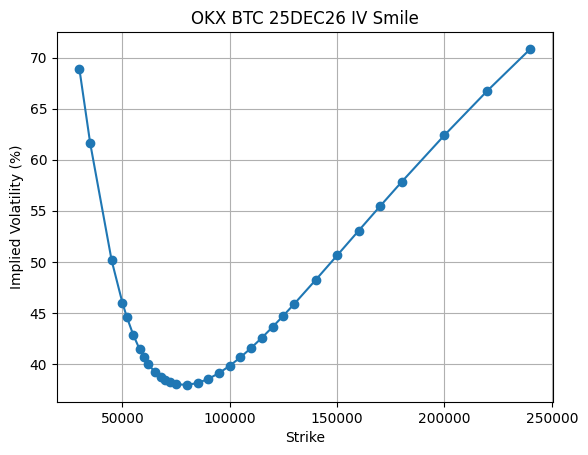

In [140]:
surface.plot_smile(options_df=okx.options_df, exchange="OKX")

In [180]:
class Bybit:
    def __init__(self, target_expiry):
         self.get_spot()
         self.get_df()
         self.get_smile(target_expiry)

    def get_spot(self):
        url = "https://api.bybit.com/v5/market/tickers"
        params = {
            "category": "spot",
            "symbol": "BTCUSDT"
        }

        data = requests.get(url=url, params=params).json()["result"]["list"][0]
        
        self.spot = float(data["lastPrice"])
        self.volume = float(data["volume24h"])
        print("spot:", self.spot, "volume24h:", self.volume)

    def get_df(self):
        contract_size = 1.0

        url = "https://api.bybit.com/v5/market/tickers"
        params = {
            "baseCoin": "BTC",
            "category": "option"
        }

        bybit_data = requests.get(url=url, params=params).json()["result"]["list"]
        bybit_df = pd.DataFrame(bybit_data)
        bybit_df = bybit_df.rename(columns={"markIv": "mark_iv", 
                                            "openInterest": "open_interest"})

        bybit_df["open_interest"] = bybit_df["open_interest"].astype(float)
        bybit_df["open_interest_notional"] = bybit_df["open_interest"] * contract_size
        bybit_df["mark_iv"] = bybit_df["mark_iv"].astype(float)

        parts = bybit_df["symbol"].str.split("-")
        bybit_df["expiry"] = pd.to_datetime(parts.str[1], format="%d%b%y").dt.strftime("%Y%m%d")
        bybit_df["strike"] = parts.str[2].astype(float)
        bybit_df["option_type"] = parts.str[3].map({"C": "call", "P": "put"})

        bybit_df["expiry_dt"] = pd.to_datetime(parts.str[1], format="%d%b%y", utc=True)
        bybit_df["T"] = (
            bybit_df["expiry_dt"] - datetime.now(timezone.utc)).dt.total_seconds() / (365.25 * 24 * 3600)
        
        bybit_df["total_variance"] = bybit_df["mark_iv"] ** 2 * bybit_df["T"]

        bybit_df = bybit_df[bybit_df["open_interest_notional"] >= 10]
        bybit_df = bybit_df.sort_values(["expiry", "strike"])

        self.bybit_df = bybit_df

    def get_smile(self, target_expiry):

        self.options_df = self.bybit_df[
            (self.bybit_df["expiry"] == target_expiry) &
            (self.bybit_df["option_type"] == "call")
        ]

        self.options_df = self.options_df.sort_values("strike")

bybit = Bybit(target_expiry=target_expiry)
bybit.options_df.head()

spot: 64437.5 volume24h: 7064.958059


,symbol,bid1Price,bid1Size,bid1Iv,ask1Price,ask1Size,ask1Iv,lastPrice,highPrice24h,lowPrice24h,...,theta,predictedDeliveryPrice,change24h,open_interest_notional,expiry,strike,option_type,expiry_dt,T,total_variance
221,BTC-25DEC26-70000-C-USDT,4475,2.53,0.3845,4545,2.53,0.3889,4295,4380,4295,...,-21.96575699,0,0.02019003,20.73,20261225,70000.0,call,2026-12-25 00:00:00+00:00,0.387134,0.057891
217,BTC-25DEC26-75000-C-USDT,2945,3.46,0.3809,2985,1.71,0.3836,2995,2995,2930,...,-19.83959067,0,0.10925926,16.09,20261225,75000.0,call,2026-12-25 00:00:00+00:00,0.387134,0.056403
182,BTC-25DEC26-80000-C-USDT,1905,7.03,0.3799,1935,5.45,0.3823,1805,1830,1705,...,-16.87243394,0,0.05865103,33.64,20261225,80000.0,call,2026-12-25 00:00:00+00:00,0.387134,0.056167
235,BTC-25DEC26-85000-C-USDT,1225,9.44,0.3812,1260,9.44,0.3847,1150,1155,1150,...,-13.76598129,0,0.05504588,17.38,20261225,85000.0,call,2026-12-25 00:00:00+00:00,0.387134,0.056848
228,BTC-25DEC26-90000-C-USDT,795,2.1,0.3848,825,12.1,0.3885,835,835,740,...,-10.95516717,0,0.12837838,18.49,20261225,90000.0,call,2026-12-25 00:00:00+00:00,0.387134,0.058221


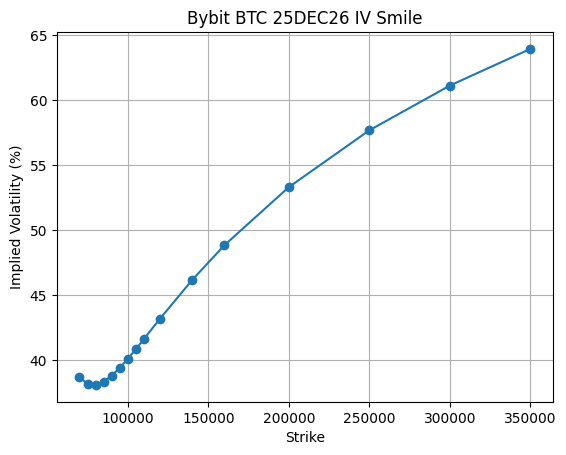

In [176]:
surface.plot_smile(options_df=bybit.options_df, exchange="Bybit")

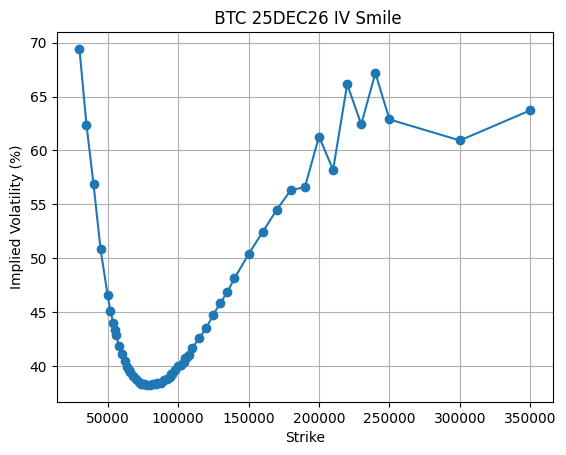

weighted spot: 64424.02316664761


In [210]:
surface.get_overall_smile(dr.options_df, okx.options_df, bybit.options_df)
surface.plot_smile(options_df=surface.curve, exchange="")
surface.get_weighted_spot(dr, okx, bybit)

In [211]:
today = datetime.now(timezone.utc)
T = (target_expiry_dt - today).total_seconds() / (365 * 24 * 60 * 60)

surface.interpolate_iv(surface.curve, required_strike)

surface.prob_touch(spot=surface.weighted_spot, 
                   strike=required_strike,
                   iv=surface.iv,
                   T=T,
                   r=0)

BTC 100000.0 strike iv: 0.39944799336870374
p_touch: 0.05793


In [212]:
today = datetime.now(timezone.utc)
T = (target_expiry_dt - today).total_seconds() / (365 * 24 * 60 * 60)

variance_surface = surface.build_variance_surface(surface=surface.surface)
total_variance = variance_surface(required_strike, T)
iv = np.sqrt(total_variance / T)


surface.prob_touch(spot=surface.weighted_spot, 
                   strike=required_strike,
                   iv=iv,
                   T=T,
                   r=0)

p_touch: 0.05933


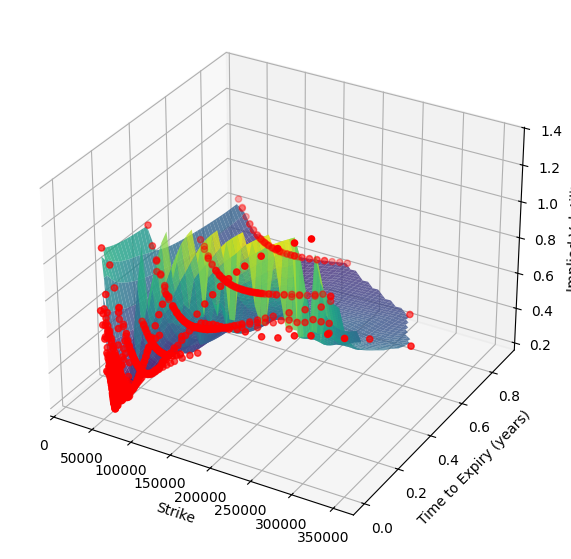

In [207]:
surface.get_surface(dr.deribit_df, okx.okx_df, bybit.bybit_df)
variance_surface = surface.build_variance_surface(surface=surface.surface)
surface.plot_surface(surface=surface.surface, variance_surface=variance_surface)

In [ ]:
# Keep trading journal

# Your thesis.
# Why you think the market is mispriced.
# Position size.
# Exit criteria.
# What actually happened.